In [ ]:
import pandas as pd
import zipfile
# CORE-POI-GEOMETRY-RICE
# 1. Đường dẫn tới CHÍNH XÁC file ZIP của bạn
zip_path = r'D:\DOWLOAD\HỌC HÀNH\hackrice\Rice WC Hack-selected (1).zip'

# 2. Tên thư mục con nằm bên trong file ZIP mà chúng ta muốn nhắm tới
target_folder = 'core-poi-geometry-rice/'

# Các cột trọng tâm cần lấy
poi_cols = [
    'PLACEKEY', 'LOCATION_NAME', 'TOP_CATEGORY', 'SUB_CATEGORY', 
    'LATITUDE', 'LONGITUDE', 'CITY', 'REGION', 'MARKET', 
    'INCLUDES_PARKING_LOT', 'WKT_AREA_SQ_METERS', 'IS_SYNTHETIC'
]

df_poi_list = []

print("Đang mở kiện hàng ZIP...")

# 3. Dùng zipfile để mở file .zip mà không cần giải nén
with zipfile.ZipFile(zip_path, 'r') as z:
    # Quét toàn bộ file bên trong, lọc ra những file thuộc thư mục POI và có đuôi .csv.gz
    file_list = [f for f in z.namelist() if target_folder in f and f.endswith('.csv.gz')]
    
    print(f"Phát hiện {len(file_list)} file dữ liệu. Đang đọc trực tiếp xuyên qua lớp nén...")
    
    # 4. Vòng lặp đọc từng file
    for file_name in file_list:
        with z.open(file_name) as f:
            # Pandas có thể đọc luồng dữ liệu truyền thẳng từ trong file ZIP ra
            df = pd.read_csv(f, usecols=lambda c: c in poi_cols, compression='gzip')
            df_poi_list.append(df)

# 5. Gộp bảng
if df_poi_list:
    df_poi_all = pd.concat(df_poi_list, ignore_index=True)
    print("\n--- HOÀN TẤT GỘP DỮ LIỆU ---")
    print(f"Tổng cộng toàn bộ dữ liệu POI có: {df_poi_all.shape[0]} dòng và {df_poi_all.shape[1]} cột.")
    
    print("\n--- 5 DÒNG ĐẦU TIÊN ---")
    display(df_poi_all.head())
else:
    print("\nKhông tìm thấy file nào! Bạn kiểm tra lại tên file ZIP hoặc cấu trúc bên trong nhé.")

Đang mở kiện hàng ZIP...
Phát hiện 32 file dữ liệu. Đang đọc trực tiếp xuyên qua lớp nén...

--- HOÀN TẤT GỘP DỮ LIỆU ---
Tổng cộng toàn bộ dữ liệu POI có: 511934 dòng và 12 cột.

--- 5 DÒNG ĐẦU TIÊN ---


,CITY,INCLUDES_PARKING_LOT,IS_SYNTHETIC,LATITUDE,LOCATION_NAME,LONGITUDE,MARKET,PLACEKEY,REGION,SUB_CATEGORY,TOP_CATEGORY,WKT_AREA_SQ_METERS
0,Houston,False,False,29.769073,Enterprise Rent-A-Car,-95.398000,Houston,223-222@8fc-9qc-9j9,TX,Passenger Car Rental,Automotive Equipment Rental and Leasing,95.4
1,Fremont,False,False,41.354662,Warren African Methodist Episcopal Church,-83.101779,San Francisco Bay Area,223-224@63j-pmh-r6k,OH,Religious Organizations,Religious Organizations,287.1
2,Dallas,False,False,32.812605,D & J Sports,-96.858680,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8
3,Dallas,False,False,32.791353,Hargrove Electric Co,-96.820791,Dallas,222-222@5qw-t3p-zvf,TX,Electronics Stores,Electronics and Appliance Stores,1271.0
4,Los Angeles,False,False,34.023633,Palms Crest Apartments,-118.412628,Los Angeles,222-222@5z4-ztv-hwk,CA,Lessors of Residential Buildings and Dwellings,Lessors of Real Estate,1191.0


In [4]:
import os

print("--- ĐANG TIẾN HÀNH LÀM SẠCH DỮ LIỆU POI ---")

# 1. Kiểm tra dữ liệu bị thiếu (missing values)
print("Số lượng dữ liệu bị thiếu ở từng cột:")
print(df_poi_all.isnull().sum())

# 2. Xóa các dòng trùng lặp (duplicates)
duplicates = df_poi_all.duplicated().sum()
print(f"\nPhát hiện {duplicates} dòng trùng lặp. Đang tiến hành xóa...")
df_poi_cleaned = df_poi_all.drop_duplicates()

# 3. Lọc bỏ các dòng thiếu khóa chính hoặc tọa độ
df_poi_cleaned = df_poi_cleaned.dropna(subset=['PLACEKEY', 'LATITUDE', 'LONGITUDE'])

print(f"Kích thước sau khi làm sạch: {df_poi_cleaned.shape[0]} dòng.")

# 4. Xuất file ra thư mục exports
# Đảm bảo thư mục exports tồn tại (nếu chưa có thì tự động tạo)
os.makedirs('../exports', exist_ok=True)

export_path_poi = '../exports/poi_summary.csv'
df_poi_cleaned.to_csv(export_path_poi, index=False)
print(f"\n✅ Đã xuất file dữ liệu POI sạch thành công tại: {export_path_poi}")

--- ĐANG TIẾN HÀNH LÀM SẠCH DỮ LIỆU POI ---
Số lượng dữ liệu bị thiếu ở từng cột:
CITY                        0
INCLUDES_PARKING_LOT    41532
IS_SYNTHETIC            32854
LATITUDE                    0
LOCATION_NAME               0
LONGITUDE                   0
MARKET                      0
PLACEKEY                    0
REGION                      2
SUB_CATEGORY            33405
TOP_CATEGORY                0
WKT_AREA_SQ_METERS      32735
dtype: int64

Phát hiện 0 dòng trùng lặp. Đang tiến hành xóa...
Kích thước sau khi làm sạch: 511934 dòng.

✅ Đã xuất file dữ liệu POI sạch thành công tại: ../exports/poi_summary.csv


In [5]:
import pandas as pd
import zipfile

# 1. Vẫn là đường dẫn tới file ZIP thần thánh của bạn
zip_path = r'D:\DOWLOAD\HỌC HÀNH\hackrice\Rice WC Hack-selected (1).zip'

# 2. Lần này chúng ta nhắm mục tiêu vào thư mục Spend
target_folder = 'spend-patterns-rice/'

# Các cột trọng tâm cho Spend (để không làm nổ RAM)
spend_cols = ['PLACEKEY', 'LOCATION_NAME', 'TOP_CATEGORY', 'LATITUDE', 'LONGITUDE', 'RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS']

df_spend_list = []

print("Đang mở kiện hàng ZIP để tìm Spend Patterns...")

# 3. Đọc trực tiếp từ ZIP
with zipfile.ZipFile(zip_path, 'r') as z:
    # Lọc ra các file thuộc thư mục Spend và có đuôi .csv.gz
    file_list = [f for f in z.namelist() if target_folder in f and f.endswith('.csv.gz')]
    
    print(f"Phát hiện {len(file_list)} file dữ liệu Spend. Đang tiến hành đọc...")
    print("(Quá trình này có thể mất vài phút vì dữ liệu giao dịch thường rất lớn, bạn đợi chút nhé!)")
    
    for file_name in file_list:
        with z.open(file_name) as f:
            df = pd.read_csv(f, usecols=lambda c: c in spend_cols, compression='gzip')
            df_spend_list.append(df)

# 4. Gộp bảng
if df_spend_list:
    df_spend_all = pd.concat(df_spend_list, ignore_index=True)
    print("\n--- HOÀN TẤT GỘP DỮ LIỆU SPEND ---")
    print(f"Tổng cộng có: {df_spend_all.shape[0]} dòng và {df_spend_all.shape[1]} cột.")
    
    print("\n--- 5 DÒNG ĐẦU TIÊN ---")
    display(df_spend_all.head())
else:
    print("\nKhông tìm thấy file Spend nào! Bạn kiểm tra lại tên thư mục nhé.")

Đang mở kiện hàng ZIP để tìm Spend Patterns...
Phát hiện 32 file dữ liệu Spend. Đang tiến hành đọc...
(Quá trình này có thể mất vài phút vì dữ liệu giao dịch thường rất lớn, bạn đợi chút nhé!)

--- HOÀN TẤT GỘP DỮ LIỆU SPEND ---
Tổng cộng có: 1026618 dòng và 7 cột.

--- 5 DÒNG ĐẦU TIÊN ---


,LATITUDE,LOCATION_NAME,LONGITUDE,PLACEKEY,RAW_NUM_CUSTOMERS,RAW_TOTAL_SPEND,TOP_CATEGORY
0,37.668486,Sprouts Farmers Market,-122.466474,222-222@5vg-847-249,786.24,68275.6620,Grocery Stores
1,39.660152,Dollar Tree,-75.736810,222-222@63s-8xy-3yv,95.04,1924.7674,"General Merchandise Stores, including Warehous..."
2,35.374957,Elysium Ink Body Art,-80.550545,222-222@8gg-37s-rff,11.88,2021.3578,Personal Care Services
3,39.057572,Meshuggah Bagels,-94.600925,223-222@5pr-6f5-m6k,29.58,641.1884,Restaurants and Other Eating Places
4,37.560351,Hobby Lobby Stores,-122.280378,223-222@5vh-7yc-qvf,13.65,750.8662,"Sporting Goods, Hobby, and Musical Instrument ..."


In [6]:
import os

print("--- ĐANG TIẾN HÀNH LÀM SẠCH DỮ LIỆU SPEND ---")

# 1. Kiểm tra dữ liệu bị thiếu (missing values)
print("Số lượng dữ liệu bị thiếu ở từng cột:")
print(df_spend_all.isnull().sum())

# 2. Xóa các dòng trùng lặp (duplicates)
duplicates_spend = df_spend_all.duplicated().sum()
print(f"\nPhát hiện {duplicates_spend} dòng trùng lặp. Đang tiến hành xóa...")
df_spend_cleaned = df_spend_all.drop_duplicates()

# 3. Lọc bỏ các dòng thiếu khóa chính hoặc tọa độ
df_spend_cleaned = df_spend_cleaned.dropna(subset=['PLACEKEY', 'LATITUDE', 'LONGITUDE'])

print(f"Kích thước sau khi làm sạch: {df_spend_cleaned.shape[0]} dòng.")

# 4. Xuất file ra thư mục exports
# Đảm bảo thư mục exports tồn tại
os.makedirs('../exports', exist_ok=True)

export_path_spend = '../exports/spending_summary.csv'
df_spend_cleaned.to_csv(export_path_spend, index=False)
print(f"\n✅ Đã xuất file dữ liệu Spend sạch thành công tại: {export_path_spend}")

--- ĐANG TIẾN HÀNH LÀM SẠCH DỮ LIỆU SPEND ---
Số lượng dữ liệu bị thiếu ở từng cột:
LATITUDE             0
LOCATION_NAME        0
LONGITUDE            0
PLACEKEY             0
RAW_NUM_CUSTOMERS    0
RAW_TOTAL_SPEND      0
TOP_CATEGORY         0
dtype: int64

Phát hiện 4 dòng trùng lặp. Đang tiến hành xóa...
Kích thước sau khi làm sạch: 1026614 dòng.

✅ Đã xuất file dữ liệu Spend sạch thành công tại: ../exports/spending_summary.csv


In [7]:
import pandas as pd
import zipfile
import os

# 1. Đường dẫn tới file ZIP quen thuộc
zip_path = r'D:\DOWLOAD\HỌC HÀNH\hackrice\Rice WC Hack-selected (1).zip'

# 2. Thư mục trùm cuối: Urban Heat Index
target_folder = 'urban-heat-index-rice/'

# Các cột trọng tâm cho UHI
uhi_cols = ['LATITUDE', 'LONGITUDE', 'UHI', 'MARKET']

df_uhi_list = []

print("Đang mở kiện hàng ZIP để tìm Urban Heat Index...")

# 3. Đọc trực tiếp từ ZIP
with zipfile.ZipFile(zip_path, 'r') as z:
    file_list = [f for f in z.namelist() if target_folder in f and f.endswith('.csv.gz')]
    
    print(f"Phát hiện {len(file_list)} file dữ liệu UHI. Đang tiến hành đọc...")
    
    for file_name in file_list:
        with z.open(file_name) as f:
            df = pd.read_csv(f, usecols=lambda c: c in uhi_cols, compression='gzip')
            df_uhi_list.append(df)

# 4. Gộp và làm sạch bảng
if df_uhi_list:
    df_uhi_all = pd.concat(df_uhi_list, ignore_index=True)
    print("\n--- HOÀN TẤT GỘP DỮ LIỆU UHI ---")
    print(f"Tổng cộng có: {df_uhi_all.shape[0]} dòng và {df_uhi_all.shape[1]} cột.")
    
    # Làm sạch: Xóa trùng lặp và loại bỏ dòng thiếu tọa độ hoặc chỉ số UHI
    df_uhi_cleaned = df_uhi_all.drop_duplicates().dropna(subset=['LATITUDE', 'LONGITUDE', 'UHI'])
    print(f"Kích thước sau khi làm sạch: {df_uhi_cleaned.shape[0]} dòng.")
    
    # 5. Xuất file ra thư mục exports
    os.makedirs('../exports', exist_ok=True)
    export_path_uhi = '../exports/uhi_summary.csv'
    df_uhi_cleaned.to_csv(export_path_uhi, index=False)
    print(f"\n✅ Đã xuất file UHI sạch thành công tại: {export_path_uhi}")
    
    # Hiển thị 5 dòng đầu tiên
    display(df_uhi_cleaned.head())
else:
    print("\nKhông tìm thấy file UHI nào! Bạn kiểm tra lại tên thư mục nhé.")

Đang mở kiện hàng ZIP để tìm Urban Heat Index...
Phát hiện 32 file dữ liệu UHI. Đang tiến hành đọc...

--- HOÀN TẤT GỘP DỮ LIỆU UHI ---
Tổng cộng có: 1229291 dòng và 4 cột.
Kích thước sau khi làm sạch: 1229291 dòng.

✅ Đã xuất file UHI sạch thành công tại: ../exports/uhi_summary.csv


,LATITUDE,LONGITUDE,MARKET,UHI
0,35.511,-80.6850,San Francisco Bay Area,1
1,35.506,-80.6895,San Francisco Bay Area,1
2,35.508,-80.6850,San Francisco Bay Area,1
3,35.508,-80.6880,San Francisco Bay Area,1
4,35.510,-80.6865,San Francisco Bay Area,1


In [8]:
import pandas as pd

print("--- GIAI ĐOẠN 3: HỢP NHẤT DỮ LIỆU POI & SPEND ---")
print("Đang tải dữ liệu sạch từ thư mục exports...")

# 1. Đọc lại dữ liệu đã làm sạch
df_poi = pd.read_csv('../exports/poi_summary.csv')
df_spend = pd.read_csv('../exports/spending_summary.csv')

print(f"Kích thước POI: {df_poi.shape[0]} dòng")
print(f"Kích thước Spend: {df_spend.shape[0]} dòng")

print("\nĐang hợp nhất (Merge) dựa trên PLACEKEY...")

# 2. Hợp nhất dữ liệu
# Lưu ý: Bảng Spend ta chỉ lấy cột PLACEKEY, SPEND và CUSTOMERS để tránh bị trùng cột Tọa độ với POI
df_merged = pd.merge(
    df_poi, 
    df_spend[['PLACEKEY', 'RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS']], 
    on='PLACEKEY', 
    how='inner' # inner join: chỉ giữ lại các địa điểm vừa có thông tin POI, vừa có lịch sử giao dịch
)

print(f"✅ Hợp nhất thành công! Siêu dữ liệu mới có {df_merged.shape[0]} dòng.")

# 3. Xem thử "hình hài" của siêu dữ liệu
display(df_merged.head())

--- GIAI ĐOẠN 3: HỢP NHẤT DỮ LIỆU POI & SPEND ---
Đang tải dữ liệu sạch từ thư mục exports...
Kích thước POI: 511934 dòng
Kích thước Spend: 1026614 dòng

Đang hợp nhất (Merge) dựa trên PLACEKEY...
✅ Hợp nhất thành công! Siêu dữ liệu mới có 894119 dòng.


,CITY,INCLUDES_PARKING_LOT,IS_SYNTHETIC,LATITUDE,LOCATION_NAME,LONGITUDE,MARKET,PLACEKEY,REGION,SUB_CATEGORY,TOP_CATEGORY,WKT_AREA_SQ_METERS,RAW_TOTAL_SPEND,RAW_NUM_CUSTOMERS
0,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,1179.7940,8.00
1,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,2810.6925,5.30
2,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,3377.9808,10.30
3,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,232.7370,5.76
4,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,247.7865,2.58


In [9]:
print("--- BƯỚC 3.2: GHÉP NỐI DỮ LIỆU NHIỆT ĐỘ (UHI) BẰNG TỌA ĐỘ ---")

# 1. Đọc dữ liệu UHI từ thư mục exports
df_uhi = pd.read_csv('../exports/uhi_summary.csv')

# 2. Làm tròn tọa độ xuống 3 chữ số thập phân (sai số khoảng 111 mét - đủ chuẩn cho khu vực đô thị)
# Tạo cột tạm thời để làm mỏ neo ghép nối
df_merged['LAT_round'] = df_merged['LATITUDE'].round(3)
df_merged['LON_round'] = df_merged['LONGITUDE'].round(3)

df_uhi['LAT_round'] = df_uhi['LATITUDE'].round(3)
df_uhi['LON_round'] = df_uhi['LONGITUDE'].round(3)

print("Đang tiến hành ghép nối không gian (Spatial Merge)...")

# 3. Hợp nhất dựa trên Tọa độ đã làm tròn
# Dùng 'left' join để giữ nguyên tất cả các cửa hàng, nếu chỗ nào không có trạm đo nhiệt độ thì để trống
df_final = pd.merge(
    df_merged, 
    df_uhi[['LAT_round', 'LON_round', 'UHI']], 
    on=['LAT_round', 'LON_round'], 
    how='left'
)

# 4. Dọn dẹp các cột tạm và các dòng bị duplicate do quá trình ghép tọa độ sinh ra (nếu có)
df_final = df_final.drop(columns=['LAT_round', 'LON_round']).drop_duplicates(subset=['PLACEKEY'])

print(f"\n✅ HOÀN TẤT! Siêu dữ liệu cuối cùng có: {df_final.shape[0]} dòng.")
print(f"Số lượng địa điểm mapping được chỉ số nhiệt độ (UHI): {df_final['UHI'].notnull().sum()} địa điểm.")

# Xem thử thành quả cuối cùng (kéo thanh cuộn ngang sang phải để thấy cột UHI)
display(df_final.head())

--- BƯỚC 3.2: GHÉP NỐI DỮ LIỆU NHIỆT ĐỘ (UHI) BẰNG TỌA ĐỘ ---
Đang tiến hành ghép nối không gian (Spatial Merge)...

✅ HOÀN TẤT! Siêu dữ liệu cuối cùng có: 40813 dòng.
Số lượng địa điểm mapping được chỉ số nhiệt độ (UHI): 19698 địa điểm.


,CITY,INCLUDES_PARKING_LOT,IS_SYNTHETIC,LATITUDE,LOCATION_NAME,LONGITUDE,MARKET,PLACEKEY,REGION,SUB_CATEGORY,TOP_CATEGORY,WKT_AREA_SQ_METERS,RAW_TOTAL_SPEND,RAW_NUM_CUSTOMERS,UHI
0,Dallas,False,False,32.812605,D & J Sports,-96.858680,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,1179.7940,8.00,NaN
59,Miami,False,False,25.780560,Walgreens,-80.221140,Miami,223-222@8fw-23h-d9z,FL,Pharmacies and Drug Stores,Health and Personal Care Stores,1393.0,2811.6834,79.05,NaN
120,Houston,False,False,29.790446,New Heights Associates,-95.398312,Houston,224-222@8fc-9qb-skf,TX,Offices of Mental Health Practitioners (except...,Offices of Other Health Practitioners,325.8,16.1304,2.12,7.0
126,Woodbridge,False,False,38.654837,Fuddruckers,-77.305129,New York/New Jersey,223-222@63r-tv4-33q,VA,Full-Service Restaurants,Restaurants and Other Eating Places,816.2,3413.1780,93.09,NaN
178,Long Beach,False,False,33.829971,Apex Chiropractic,-118.098412,New York/New Jersey,22r-222@5z6-3kh-bzf,CA,Offices of Chiropractors,Offices of Other Health Practitioners,1424.7,820.0000,2.16,7.0


--- GENERATING VISUALIZATIONS ---


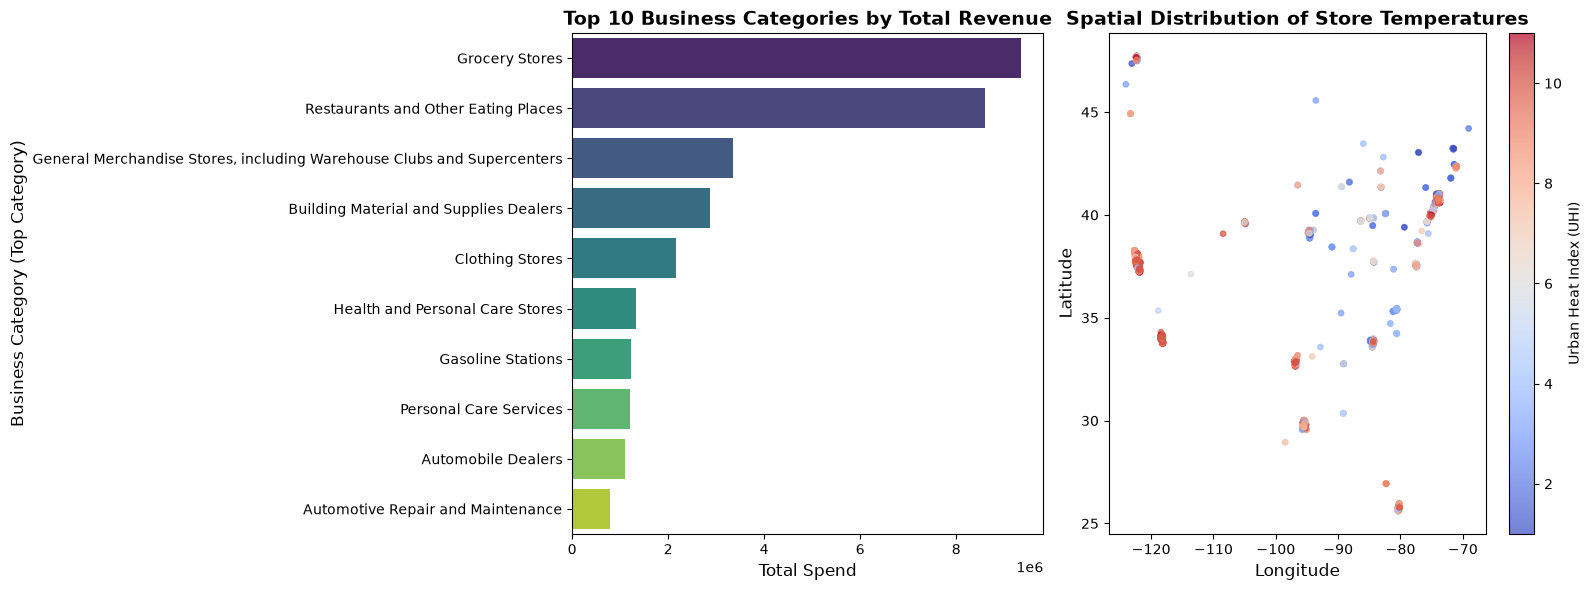

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- GENERATING VISUALIZATIONS ---")

# Lọc bỏ các dòng không có dữ liệu nhiệt độ để vẽ bản đồ cho chính xác
df_plot = df_final.dropna(subset=['UHI']).copy()

# Thiết lập khung tranh vẽ (gồm 2 biểu đồ nằm ngang)
plt.figure(figsize=(16, 6))

# --- BIỂU ĐỒ 1: TOP CATEGORIES BY REVENUE ---
plt.subplot(1, 2, 1)
# Tính tổng doanh thu theo từng danh mục và lấy Top 10
top_categories = df_plot.groupby('TOP_CATEGORY')['RAW_TOTAL_SPEND'].sum().nlargest(10)

# Vẽ biểu đồ cột ngang (đã thêm hue và legend=False để fix cảnh báo)
sns.barplot(
    x=top_categories.values, 
    y=top_categories.index, 
    hue=top_categories.index, 
    palette='viridis', 
    legend=False
)
plt.title('Top 10 Business Categories by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend', fontsize=12)
plt.ylabel('Business Category (Top Category)', fontsize=12)

# --- BIỂU ĐỒ 2: URBAN HEAT INDEX MAP ---
plt.subplot(1, 2, 2)
# Lấy ngẫu nhiên 5000 điểm để vẽ cho mượt
df_sample = df_plot.sample(n=min(5000, len(df_plot)), random_state=42)

# Vẽ các điểm lên hệ trục tọa độ
scatter = plt.scatter(df_sample['LONGITUDE'], df_sample['LATITUDE'], 
                      c=df_sample['UHI'], cmap='coolwarm', alpha=0.7, s=15)

plt.colorbar(scatter, label='Urban Heat Index (UHI)')
plt.title('Spatial Distribution of Store Temperatures', fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Hiển thị
plt.tight_layout()
plt.show()

In [13]:
print("--- GIAI ĐOẠN CUỐI: TÌM KIẾM KHU VỰC VÀNG (ZONE RECOMMENDATIONS) ---")

# 1. Lấy danh sách 2 ngành hàng có doanh thu cao nhất (Grocery và Restaurants)
top_2_categories = top_categories.index[:2].tolist()

# 2. Lọc dữ liệu theo 3 tiêu chí khắt khe:
# - Thuộc Top 2 ngành hàng hút khách nhất
# - BẮT BUỘC phải có bãi đậu xe (INCLUDES_PARKING_LOT == True)
# - Chỉ số Đảo nhiệt (UHI) thấp hoặc trung bình (<= 4) để đảm bảo không gian ngoài trời thoáng mát
df_recommendations = df_final[
    (df_final['TOP_CATEGORY'].isin(top_2_categories)) & 
    (df_final['INCLUDES_PARKING_LOT'] == True) & 
    (df_final['UHI'] <= 4.0)
].copy()

# 3. Sắp xếp ưu tiên theo Doanh thu và Lượng khách
df_recommendations = df_recommendations.sort_values(
    by=['RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS'], 
    ascending=[False, False]
)

# 4. Xuất file cho Admin
export_path_rec = '../exports/zone_recommendations.csv'
df_recommendations.to_csv(export_path_rec, index=False)

print(f"✅ Đã tìm thấy {df_recommendations.shape[0]} địa điểm 'Vàng' đạt chuẩn!")
print(f"✅ Đã xuất file báo cáo tại: {export_path_rec}")

# Hiển thị Top 5 địa điểm hoàn hảo nhất
display(df_recommendations[['LOCATION_NAME', 'CITY', 'TOP_CATEGORY', 'UHI', 'RAW_TOTAL_SPEND']].head())

--- GIAI ĐOẠN CUỐI: TÌM KIẾM KHU VỰC VÀNG (ZONE RECOMMENDATIONS) ---
✅ Đã tìm thấy 5 địa điểm 'Vàng' đạt chuẩn!
✅ Đã xuất file báo cáo tại: ../exports/zone_recommendations.csv


,LOCATION_NAME,CITY,TOP_CATEGORY,UHI,RAW_TOTAL_SPEND
352045,24 Seven,Houston,Grocery Stores,3.0,19509.4416
80773,Lincoln Food Mart,Seattle,Grocery Stores,2.0,3409.4823
495780,Dunkin',Plainfield,Restaurants and Other Eating Places,2.0,1887.5670
846251,D D's Food Mart,Union,Grocery Stores,3.0,104.1402
260127,Jackson Park Short Stop,Concord,Grocery Stores,2.0,10.8780


--- KHÔI PHỤC DỮ LIỆU & VẼ 2 BIỂU ĐỒ TĨNH BỔ SUNG ---


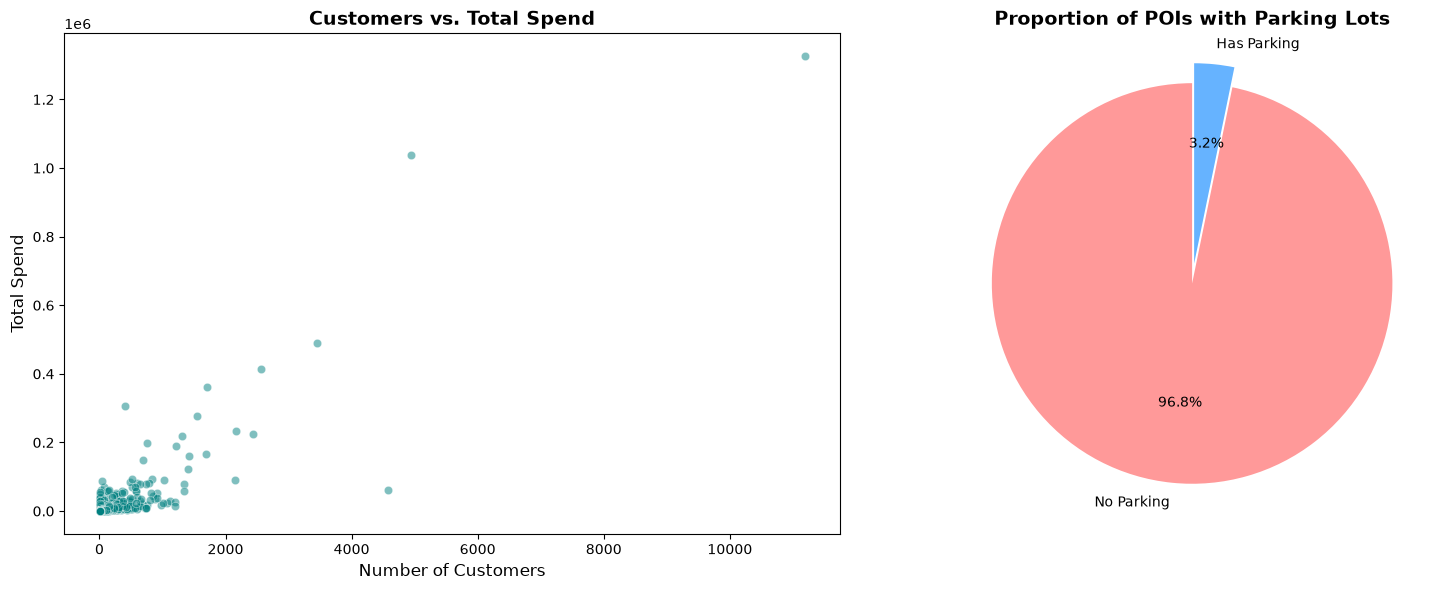

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- KHÔI PHỤC DỮ LIỆU & VẼ 2 BIỂU ĐỒ TĨNH BỔ SUNG ---")

# 1. Nạp lại dữ liệu từ thư mục exports (phòng trường hợp RAM bị xóa)
df_poi = pd.read_csv('../exports/poi_summary.csv')
df_spend = pd.read_csv('../exports/spending_summary.csv')
df_uhi = pd.read_csv('../exports/uhi_summary.csv')

# 2. Lắp ráp lại df_final
df_merged = pd.merge(df_poi, df_spend[['PLACEKEY', 'RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS']], on='PLACEKEY', how='inner')
df_merged['LAT_round'] = df_merged['LATITUDE'].round(3)
df_merged['LON_round'] = df_merged['LONGITUDE'].round(3)
df_uhi['LAT_round'] = df_uhi['LATITUDE'].round(3)
df_uhi['LON_round'] = df_uhi['LONGITUDE'].round(3)

df_final = pd.merge(df_merged, df_uhi[['LAT_round', 'LON_round', 'UHI']], on=['LAT_round', 'LON_round'], how='left')
df_final = df_final.drop(columns=['LAT_round', 'LON_round']).drop_duplicates(subset=['PLACEKEY'])

# 3. Vẽ 2 biểu đồ tĩnh bổ sung
plt.figure(figsize=(16, 6))

# --- BIỂU ĐỒ 3: CUSTOMERS VS TOTAL SPEND (Theo gợi ý Spend Patterns) ---
plt.subplot(1, 2, 1)
df_scatter = df_final.sample(n=min(5000, len(df_final)), random_state=42)
sns.scatterplot(data=df_scatter, x='RAW_NUM_CUSTOMERS', y='RAW_TOTAL_SPEND', alpha=0.5, color='teal')
plt.title('Customers vs. Total Spend', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Total Spend', fontsize=12)

# --- BIỂU ĐỒ 4: PARKING VS NON-PARKING POIs (Theo gợi ý POI) ---
plt.subplot(1, 2, 2)
parking_counts = df_final['INCLUDES_PARKING_LOT'].value_counts()
plt.pie(parking_counts, labels=['No Parking', 'Has Parking'], autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff'], startangle=90, explode=(0, 0.1))
plt.title('Proportion of POIs with Parking Lots', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [3]:
import folium

print("--- TẠO BẢN ĐỒ TƯƠNG TÁC (INTERACTIVE MAP) CHO THỊ TRƯỜNG DALLAS ---")

# Lọc dữ liệu khu vực Dallas và có thông tin nhiệt độ
df_dallas = df_final[(df_final['CITY'] == 'Dallas') & (df_final['UHI'].notnull())].copy()

# Sample 500 điểm để bản đồ chạy mượt (Guide Book nhắc: Do not show more than one million markers)
df_dallas_sample = df_dallas.sample(n=min(500, len(df_dallas)), random_state=42)

# Khởi tạo bản đồ Folium
m = folium.Map(location=[df_dallas_sample['LATITUDE'].mean(), df_dallas_sample['LONGITUDE'].mean()], zoom_start=11)

# Thêm các điểm lên bản đồ: Màu đỏ nếu nóng (UHI > 7), màu xanh nếu mát mẻ
for idx, row in df_dallas_sample.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=6,
        popup=f"Name: {row['LOCATION_NAME']}<br>Spend: ${row['RAW_TOTAL_SPEND']:.0f}<br>UHI: {row['UHI']}",
        color='red' if row['UHI'] > 7 else 'blue',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

# Hiển thị bản đồ ngay trong Notebook
display(m)

--- TẠO BẢN ĐỒ TƯƠNG TÁC (INTERACTIVE MAP) CHO THỊ TRƯỜNG DALLAS ---
